# Nairobi Urban Forest Analysis
Correlation analysis of NDVI, NDBI, and LST for 2004–2024 using Landsat imagery.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../src')

from spectral_index import extract_imagery
from gee_helpers import authenticate_ee, request_gee_image, get_utm_crs

import ee
import eemont
import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

In [2]:
authenticate_ee()

## ROI

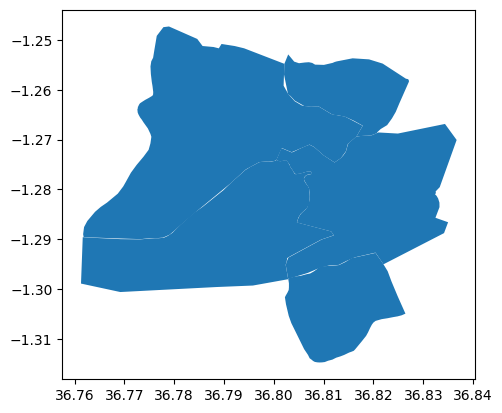

In [3]:
import fiona
# Path to the input GPKG file containing multiple layers
input_gpkg = '../data/ROI-Final-2.gpkg'

# List all layers in the GeoPackage
layers = fiona.listlayers(input_gpkg)

# Read and collect all layers into a list of GeoDataFrames
gdfs = []
for layer in layers:
    gdf = gpd.read_file(input_gpkg, layer=layer)
    gdf['source_layer'] = layer  # Track original layer
    gdfs.append(gdf)

# Merge all layers into a single GeoDataFrame
roi_gdf = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=gdfs[0].crs)

# Optionally, write merged GeoDataFrame to file (uncomment if needed)
# merged_gdf.to_file('../data/merged_layers.gpkg', driver='GPKG')

roi_gdf = roi_gdf[['Name', 'geometry']]
roi_gdf.rename(columns={'Name': 'gaul2_name'}, inplace=True)
roi_gdf = roi_gdf[~roi_gdf['gaul2_name'].isna()]
bbox = roi_gdf.total_bounds.tolist()  # [minx, miny, maxx, maxy]
utm_crs = get_utm_crs(bbox)
roi_gdf.plot()
plt.show()

In [4]:
bbox = roi_gdf.total_bounds.tolist()  # [minx, miny, maxx, maxy]
utm_crs = get_utm_crs(bbox)
print(f'BBox: {bbox}')
print(f'UTM CRS: {utm_crs}')

roi_ee = ee.Geometry.Rectangle([bbox[:2], bbox[2:]])

BBox: [36.76129069411154, -1.314737732047595, 36.8366971430228, -1.247304014148504]
UTM CRS: EPSG:32737


## Configuration

In [37]:
# Satellite configuration per year
# Landsat 7: 1999-present (SLC failure from 2003 but still usable), Landsat 8: 2013-present
YEARS = list(range(2016, 2025))

LANDSAT7_PATH = 'LANDSAT/LE07/C02/T1_L2'
LANDSAT8_PATH = 'LANDSAT/LC08/C02/T1_L2'

SPECTRAL_INDEXES = ['NDVI', 'NDBI']
CLOUD_COVERAGE = 20
SCALE = 30
N_SAMPLES = 2000

# 5-year period assignment
def get_period(year):
    if year <= 2008:
        return '2004-2008'
    elif year <= 2013:
        return '2009-2013'
    elif year <= 2018:
        return '2014-2018'
    else:
        return '2019-2024'

# PERIOD_ORDER = ['2004-2008', '2009-2013', '2014-2018', '2019-2024']
PERIOD_ORDER = ['2014-2018', '2019-2024']

## Helper Functions

In [38]:
def get_landsat_config(year):
    """Return GEE path and LST band name for a given year.
    
    Uses Landsat 7 for 2004-2012 (ST_B6) and Landsat 8 for 2013+ (ST_B10).
    Both use the same Collection 2 scale factor: 0.00341802, offset: 149.0.
    """
    if year <= 2012:
        return LANDSAT7_PATH, 'ST_B6', 'CLOUD_COVER'
    else:
        return LANDSAT8_PATH, 'ST_B10', 'CLOUD_COVER'


def calculate_lst_from_image(image, lst_band):
    """Compute LST in Celsius from a Landsat Collection 2 image."""
    thermal = image.select(lst_band)
    lst = thermal.multiply(0.00341802).add(149.0).add(-273.15).rename('LST')
    return lst


def sample_feature_info(feature):
    """Extract NDVI, NDBI, LST and coordinates from an EE Feature."""
    return ee.Feature(feature.geometry(), {
        'LST': feature.get('LST'),
        'NDVI': feature.get('NDVI'),
        'NDBI': feature.get('NDBI'),
        'lat': feature.geometry().coordinates()[1],
        'lon': feature.geometry().coordinates()[0],
    })

## Data Extraction

Extract NDVI, NDBI, and LST sample points for January–February of each year 2004–2024.
Uses Landsat 7 for 2004–2012 and Landsat 8 for 2013–2024.

In [39]:
all_dfs = []

for year in YEARS:
    print(f'Extracting {year}...', end=' ')

    ee_path, lst_band, cloud_prop = get_landsat_config(year)
    start_date = f'{year}-01-01'
    end_date = f'{year}-02-28'  # January and February only

    roi_ic = request_gee_image(ee_path, start_date, end_date, bbox)

    # Apply cloud filter; fall back to a higher threshold if no images pass
    filtered = roi_ic.filter(ee.Filter.lt(cloud_prop, CLOUD_COVERAGE))
    if filtered.size().getInfo() == 0:
        print(f'(no images at <{CLOUD_COVERAGE}% cloud, relaxing to <50%)...', end=' ')
        filtered = roi_ic.filter(ee.Filter.lt(cloud_prop, 50))
    if filtered.size().getInfo() == 0:
        print(f'(still empty, using all images)...', end=' ')
        filtered = roi_ic

    # Spectral indices
    spectral_ic = (
        filtered
        .spectralIndices(SPECTRAL_INDEXES)
        .mean()
        .select(SPECTRAL_INDEXES)
    )

    # LST
    mean_ic = filtered.mean()
    lst_img = calculate_lst_from_image(mean_ic, lst_band)

    # Combined image
    combined = spectral_ic.addBands(lst_img)

    # Sample
    samples_ee = combined.sample(
        region=roi_ee,
        scale=SCALE,
        numPixels=N_SAMPLES,
        geometries=True,
        seed=42,
    )
    cleaned = samples_ee.map(sample_feature_info)

    data = [feat['properties'] for feat in cleaned.getInfo()['features']]
    year_df = pd.DataFrame(data)
    year_df['year'] = year
    year_df['period'] = get_period(year)
    year_df['satellite'] = 'Landsat7' if year <= 2012 else 'Landsat8'

    all_dfs.append(year_df)
    print(f'n={len(year_df)}')

sample_df = pd.concat(all_dfs, ignore_index=True)
sample_df = sample_df.dropna(subset=['NDVI', 'NDBI', 'LST'])
print(f'\nTotal samples: {len(sample_df)}')
sample_df.head()

Extracting 2016... n=1947
Extracting 2017... n=1947
Extracting 2018... n=1947
Extracting 2019... n=1947
Extracting 2020... n=1947
Extracting 2021... n=1947
Extracting 2022... n=1947
Extracting 2023... n=1947
Extracting 2024... n=1947

Total samples: 17523


,LST,NDBI,NDVI,lat,lon,year,period,satellite
0,31.376746,-0.120620,0.297283,-1.249017,36.782725,2016,2014-2018,Landsat8
1,39.268954,-0.087359,0.279915,-1.288274,36.807531,2016,2014-2018,Landsat8
2,31.026399,-0.162450,0.352448,-1.269136,36.783456,2016,2014-2018,Landsat8
3,38.751124,0.045925,0.124104,-1.253402,36.793460,2016,2014-2018,Landsat8
4,35.263035,-0.102184,0.273447,-1.268987,36.803952,2016,2014-2018,Landsat8


In [40]:
# Spatial join with ROI
sample_gdf = gpd.GeoDataFrame(
    sample_df,
    geometry=gpd.points_from_xy(sample_df.lon, sample_df.lat),
    crs='EPSG:4326'
)

# Check which column to use for area names
print('ROI columns:', roi_gdf.columns.tolist())
name_col = roi_gdf.columns[0]  # adjust if needed
print(f'Using column: {name_col}')
print(roi_gdf[[name_col]].head())

ROI columns: ['gaul2_name', 'geometry']
Using column: gaul2_name
             gaul2_name
0                   CBD
1              KILIMANI
2     PARKLANDS POLYGON
3             UPPERHILL
4  WESTLANDS KILELESHWA


In [41]:
# Identify the name column from ROI (adjust if needed after inspecting output above)
name_col = roi_gdf.columns[0]  # update this if ROI has a specific name column

sample_gdf = sample_gdf.sjoin(
    roi_gdf[[name_col, 'geometry']].to_crs('EPSG:4326'),
    how='left'
)
sample_gdf[name_col] = sample_gdf[name_col].fillna('Outside')
sample_gdf = sample_gdf.drop(columns=['index_right'], errors='ignore')
sample_gdf = sample_gdf.reset_index(drop=True)
sample_df = pd.DataFrame(sample_gdf.drop(columns='geometry'))

print(sample_df.shape)
sample_df.head()

(17532, 9)


,LST,NDBI,NDVI,lat,lon,year,period,satellite,gaul2_name
0,31.376746,-0.120620,0.297283,-1.249017,36.782725,2016,2014-2018,Landsat8,WESTLANDS KILELESHWA
1,39.268954,-0.087359,0.279915,-1.288274,36.807531,2016,2014-2018,Landsat8,KILIMANI
2,31.026399,-0.162450,0.352448,-1.269136,36.783456,2016,2014-2018,Landsat8,WESTLANDS KILELESHWA
3,38.751124,0.045925,0.124104,-1.253402,36.793460,2016,2014-2018,Landsat8,WESTLANDS KILELESHWA
4,35.263035,-0.102184,0.273447,-1.268987,36.803952,2016,2014-2018,Landsat8,WESTLANDS KILELESHWA


In [42]:
# Save for reuse
sample_df.to_csv('../data/samples_2004_2024.csv', index=False)
print('Saved to data/samples_2004_2024.csv')

Saved to data/samples_2004_2024.csv


## Load Pre-extracted Data (run this cell instead of extraction if data already saved)

In [ ]:
# sample_df = pd.read_csv('../data/samples_2004_2024.csv')
# print(sample_df.shape)
# sample_df.head()

## Exploratory Overview

In [43]:
# Sample counts per year
print(sample_df.groupby('year')[['NDVI', 'NDBI', 'LST']].agg(['count', 'mean']).round(3))

      NDVI         NDBI          LST        
     count   mean count   mean count    mean
year                                        
2016  1948  0.211  1948 -0.054  1948  36.823
2017  1948  0.177  1948 -0.030  1948  34.884
2018  1948  0.189  1948 -0.042  1948  35.212
2019  1948  0.180  1948 -0.031  1948  36.850
2020  1948  0.208  1948 -0.050  1948  40.788
2021  1948  0.159  1948 -0.040  1948  29.173
2022  1948  0.197  1948 -0.048  1948  34.146
2023  1948  0.168  1948 -0.026  1948  36.870
2024  1948  0.197  1948 -0.046  1948  36.870


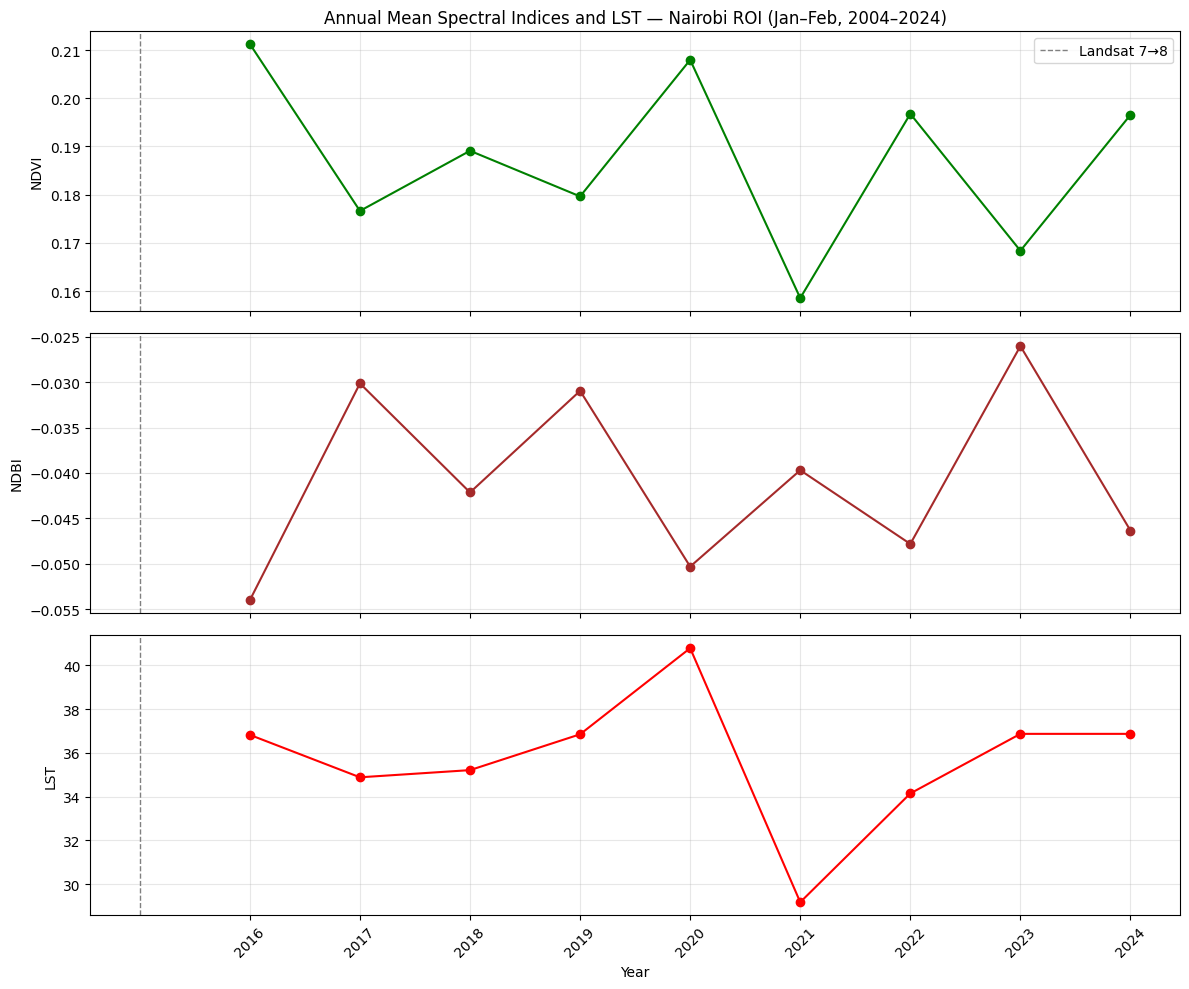

In [44]:
# Annual means
annual_means = sample_df.groupby('year')[['NDVI', 'NDBI', 'LST']].mean()

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, var, color in zip(axes, ['NDVI', 'NDBI', 'LST'], ['green', 'brown', 'red']):
    ax.plot(annual_means.index, annual_means[var], marker='o', color=color)
    ax.axvline(2015, color='grey', linestyle='--', linewidth=1, label='Landsat 7→8')
    ax.set_ylabel(var)
    ax.grid(True, alpha=0.3)

axes[0].set_title('Annual Mean Spectral Indices and LST — Nairobi ROI (Jan–Feb, 2004–2024)')
axes[0].legend()
axes[2].set_xlabel('Year')
axes[2].set_xticks(YEARS)
axes[2].set_xticklabels(YEARS, rotation=45)

plt.tight_layout()
plt.savefig('../images/annual_means_2004_2024.png', dpi=150, bbox_inches='tight')
plt.show()

## Yearly Correlation Analysis

In [45]:
# Compute Pearson correlations per year
corr_rows = []
for year, grp in sample_df.groupby('year'):
    n = len(grp)
    for x, y in [('NDVI', 'LST'), ('NDBI', 'LST'), ('NDVI', 'NDBI')]:
        valid = grp[[x, y]].dropna()
        r, p = stats.pearsonr(valid[x], valid[y])
        corr_rows.append({'year': year, 'pair': f'{x}–{y}', 'r': r, 'p': p, 'n': len(valid)})

corr_df = pd.DataFrame(corr_rows)
corr_df['period'] = corr_df['year'].apply(get_period)
corr_df.head(9)

,year,pair,r,p,n,period
0,2016,NDVI–LST,-0.748553,0.000000e+00,1948,2014-2018
1,2016,NDBI–LST,0.771235,0.000000e+00,1948,2014-2018
2,2016,NDVI–NDBI,-0.939514,0.000000e+00,1948,2014-2018
3,2017,NDVI–LST,-0.665546,1.539857e-249,1948,2014-2018
4,2017,NDBI–LST,0.720040,4.012219e-311,1948,2014-2018
5,2017,NDVI–NDBI,-0.913755,0.000000e+00,1948,2014-2018
6,2018,NDVI–LST,-0.735039,0.000000e+00,1948,2014-2018
7,2018,NDBI–LST,0.768757,0.000000e+00,1948,2014-2018
8,2018,NDVI–NDBI,-0.929906,0.000000e+00,1948,2014-2018


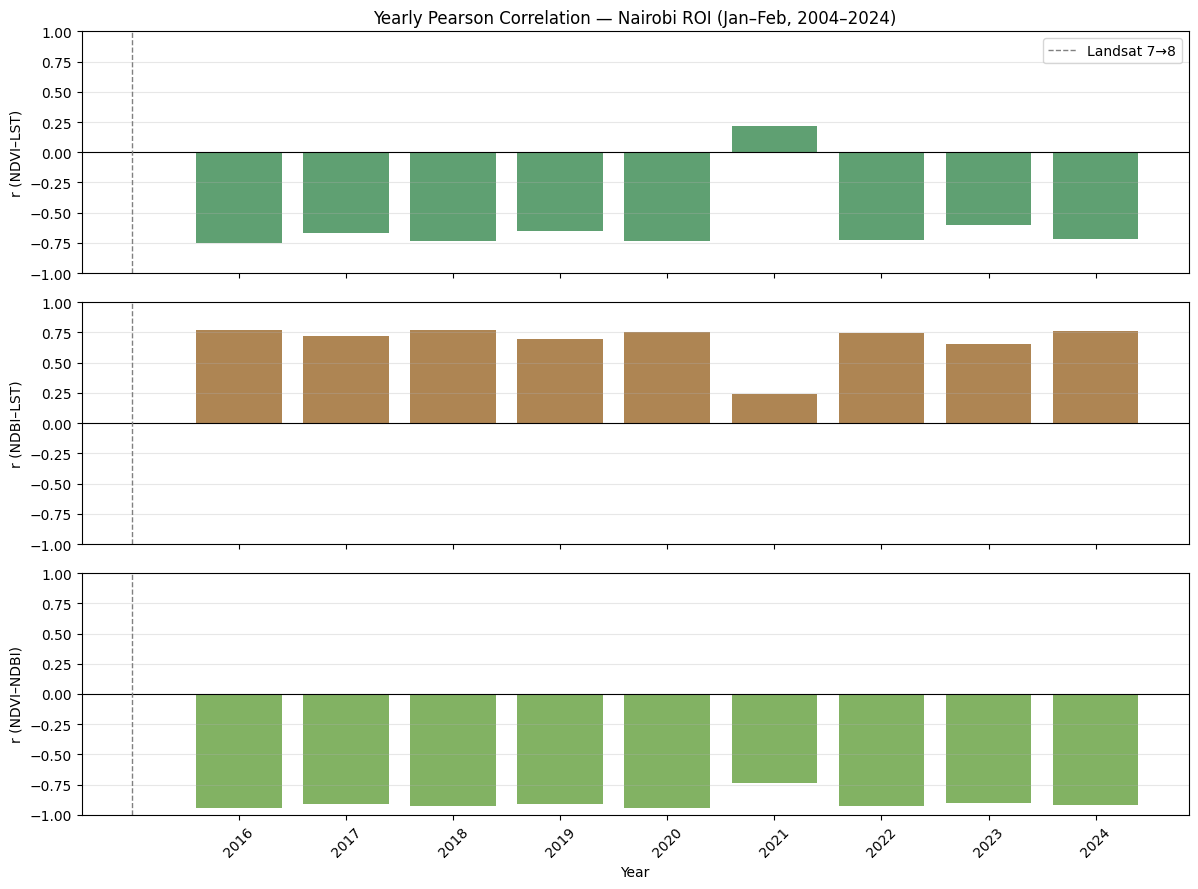

In [46]:
# Plot yearly correlations for each pair
pairs = corr_df['pair'].unique()
colors = {'NDVI–LST': '#1b7837', 'NDBI–LST': '#8c510a', 'NDVI–NDBI': '#4d9221'}

fig, axes = plt.subplots(len(pairs), 1, figsize=(12, 3 * len(pairs)), sharex=True)
if len(pairs) == 1:
    axes = [axes]

for ax, pair in zip(axes, pairs):
    sub = corr_df[corr_df['pair'] == pair].sort_values('year')
    ax.bar(sub['year'], sub['r'], color=colors.get(pair, 'steelblue'), alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(2015, color='grey', linestyle='--', linewidth=1, label='Landsat 7→8')
    ax.set_ylabel(f'r ({pair})')
    ax.set_ylim(-1, 1)
    ax.grid(True, alpha=0.3, axis='y')

axes[0].set_title('Yearly Pearson Correlation — Nairobi ROI (Jan–Feb, 2004–2024)')
axes[0].legend()
axes[-1].set_xlabel('Year')
axes[-1].set_xticks(YEARS)
axes[-1].set_xticklabels(YEARS, rotation=45)

plt.tight_layout()
plt.savefig('../images/yearly_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 5-Year Period Correlation Analysis

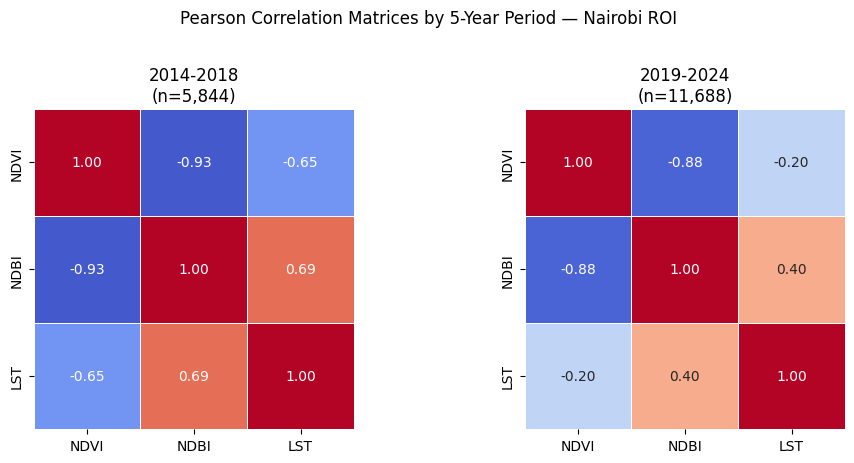

In [47]:
# Correlation matrices per 5-year period
fig, axes = plt.subplots(1, len(PERIOD_ORDER), figsize=(5 * len(PERIOD_ORDER), 4.5))

for ax, period in zip(axes, PERIOD_ORDER):
    sub = sample_df[sample_df['period'] == period][['NDVI', 'NDBI', 'LST']].dropna()
    corr_matrix = sub.corr(method='pearson')
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(
        corr_matrix,
        ax=ax,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        square=True,
        cbar=False,
        linewidths=0.5,
    )
    ax.set_title(f'{period}\n(n={len(sub):,})')

fig.suptitle('Pearson Correlation Matrices by 5-Year Period — Nairobi ROI', y=1.02)
plt.tight_layout()
plt.savefig('../images/period_correlation_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [54]:
sub

,period,pair,r,p,n
2,2014-2018,NDVI–NDBI,-0.930740,0.0,5844
5,2019-2024,NDVI–NDBI,-0.884502,0.0,11688


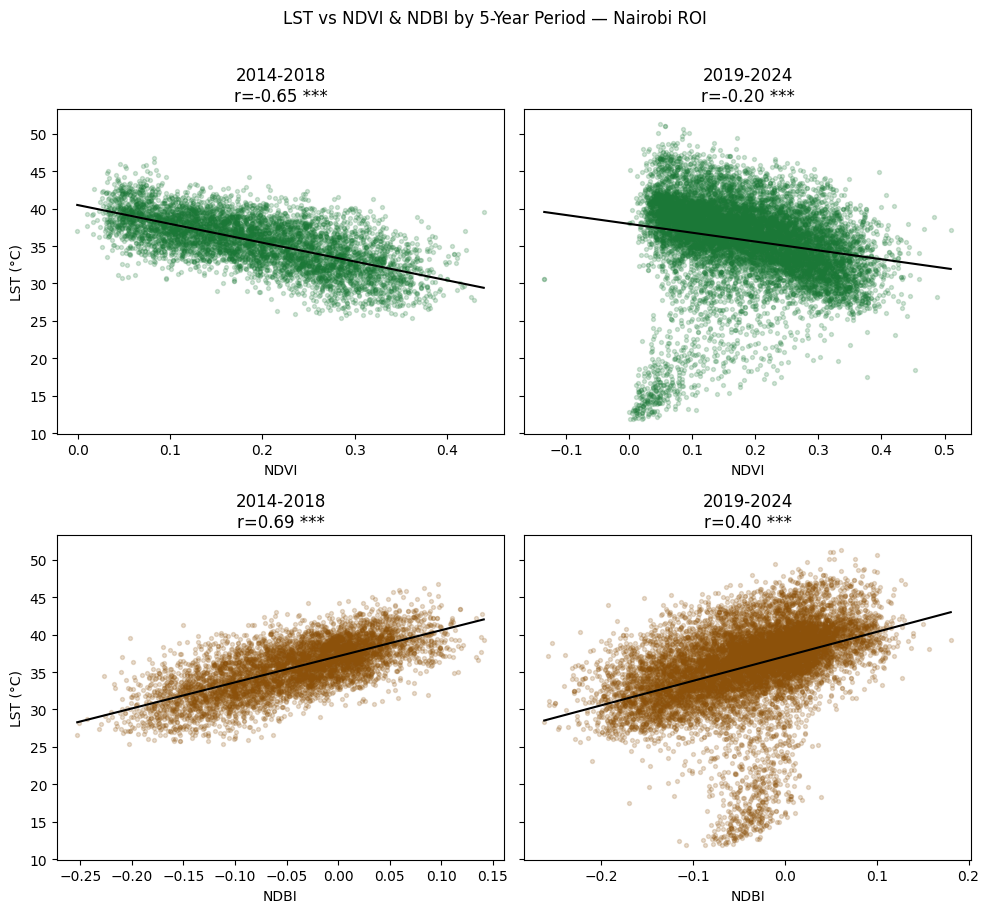

In [55]:
# Scatter plots: NDVI vs LST and NDBI vs LST per period
fig, axes = plt.subplots(2, len(PERIOD_ORDER), figsize=(5 * len(PERIOD_ORDER), 9), sharey='row')

for col, period in enumerate(PERIOD_ORDER):
    sub = sample_df[sample_df['period'] == period].dropna(subset=['NDVI', 'NDBI', 'LST'])

    for row, (x_var, color) in enumerate([('NDVI', '#1b7837'), ('NDBI', '#8c510a')]):
        ax = axes[row][col]
        ax.scatter(sub[x_var], sub['LST'], alpha=0.2, s=8, color=color, rasterized=True)

        # Regression line
        valid = sub[[x_var, 'LST']].dropna()
        m, b, r, p, _ = stats.linregress(valid[x_var], valid['LST'])
        x_line = np.linspace(valid[x_var].min(), valid[x_var].max(), 100)
        ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5)

        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        ax.set_title(f'{period}\nr={r:.2f} {sig}')
        ax.set_xlabel(x_var)
        if col == 0:
            ax.set_ylabel('LST (°C)')

fig.suptitle('LST vs NDVI & NDBI by 5-Year Period — Nairobi ROI', y=1.01)
plt.tight_layout()
plt.savefig('../images/period_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## Correlation Trend Over Time

In [50]:
# Period-level aggregated correlations
period_corr_rows = []
for period in PERIOD_ORDER:
    sub = sample_df[sample_df['period'] == period]
    for x, y in [('NDVI', 'LST'), ('NDBI', 'LST'), ('NDVI', 'NDBI')]:
        valid = sub[[x, y]].dropna()
        r, p = stats.pearsonr(valid[x], valid[y])
        period_corr_rows.append({'period': period, 'pair': f'{x}–{y}', 'r': r, 'p': p, 'n': len(valid)})

period_corr_df = pd.DataFrame(period_corr_rows)
period_corr_df['period'] = pd.Categorical(period_corr_df['period'], categories=PERIOD_ORDER, ordered=True)
print(period_corr_df.to_string(index=False))

   period      pair         r             p     n
2014-2018  NDVI–LST -0.649931  0.000000e+00  5844
2014-2018  NDBI–LST  0.691592  0.000000e+00  5844
2014-2018 NDVI–NDBI -0.930740  0.000000e+00  5844
2019-2024  NDVI–LST -0.200061 8.170165e-106 11688
2019-2024  NDBI–LST  0.401452  0.000000e+00 11688
2019-2024 NDVI–NDBI -0.884502  0.000000e+00 11688


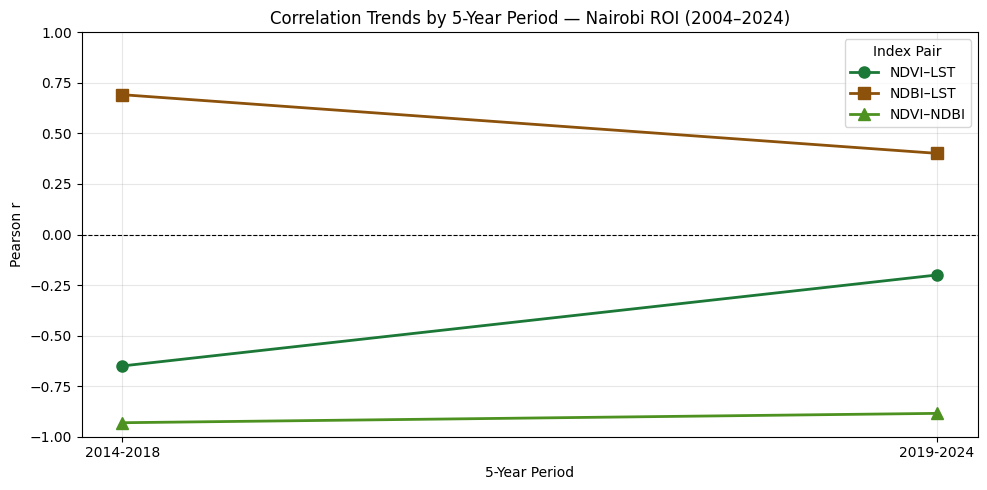

In [51]:
# Period correlation trend plot
fig, ax = plt.subplots(figsize=(10, 5))

pair_colors = {'NDVI–LST': '#1b7837', 'NDBI–LST': '#8c510a', 'NDVI–NDBI': '#4d9221'}
pair_markers = {'NDVI–LST': 'o', 'NDBI–LST': 's', 'NDVI–NDBI': '^'}

for pair in period_corr_df['pair'].unique():
    sub = period_corr_df[period_corr_df['pair'] == pair].sort_values('period')
    ax.plot(
        sub['period'].astype(str),
        sub['r'],
        marker=pair_markers[pair],
        color=pair_colors[pair],
        linewidth=2,
        markersize=8,
        label=pair
    )

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylim(-1, 1)
ax.set_xlabel('5-Year Period')
ax.set_ylabel('Pearson r')
ax.set_title('Correlation Trends by 5-Year Period — Nairobi ROI (2004–2024)')
ax.legend(title='Index Pair')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../images/period_correlation_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## Distribution of Indices by Period

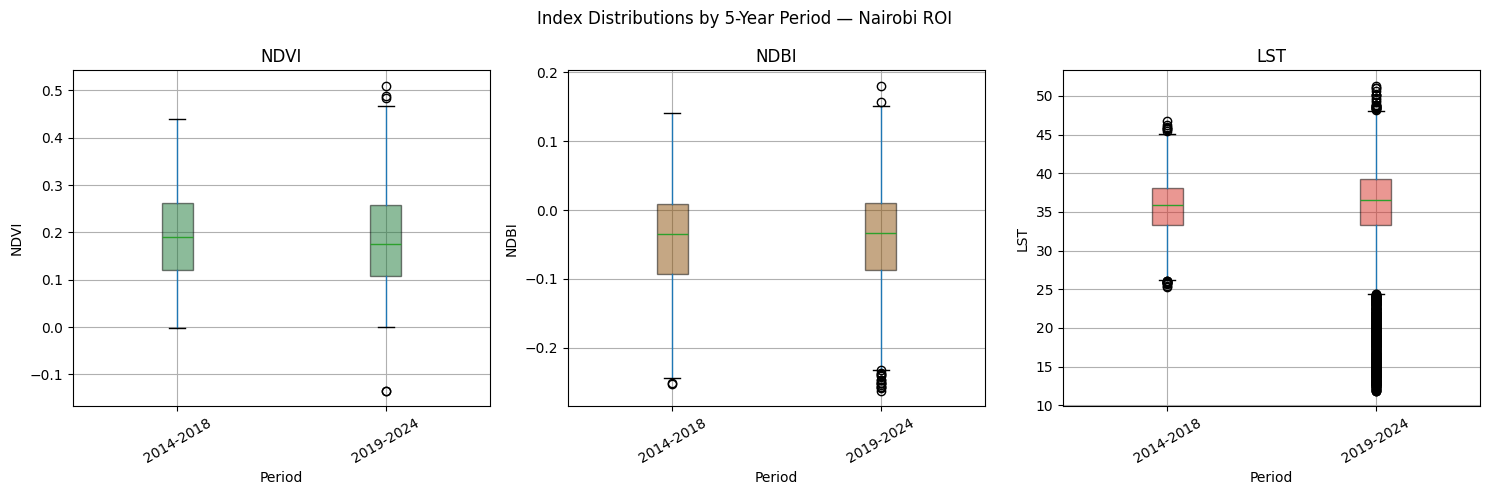

In [52]:
# Box plots per period
sample_df['period'] = pd.Categorical(sample_df['period'], categories=PERIOD_ORDER, ordered=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, var, color in zip(axes, ['NDVI', 'NDBI', 'LST'], ['#1b7837', '#8c510a', '#d73027']):
    sample_df.boxplot(column=var, by='period', ax=ax, notch=False, patch_artist=True,
                      boxprops=dict(facecolor=color, alpha=0.5))
    ax.set_title(var)
    ax.set_xlabel('Period')
    ax.set_ylabel(var)
    plt.sca(ax)
    plt.xticks(rotation=30)

fig.suptitle('Index Distributions by 5-Year Period — Nairobi ROI')
plt.tight_layout()
plt.savefig('../images/period_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## Raster Extraction (optional — saves GeoTIFFs per year)

In [ ]:
# Uncomment to run — this saves full raster GeoTIFFs for each year

for year in YEARS:
    print(f'Raster extraction {year}...')
    ee_path, lst_band, cloud_prop = get_landsat_config(year)
    start_date = f'{year}-01-01'
    end_date = f'{year}-02-28'

    roi_ic = request_gee_image(ee_path, start_date, end_date, bbox)
    filtered = roi_ic.filter(ee.Filter.lt(cloud_prop, CLOUD_COVERAGE))
    if filtered.size().getInfo() == 0:
        filtered = roi_ic.filter(ee.Filter.lt(cloud_prop, 50))
    if filtered.size().getInfo() == 0:
        filtered = roi_ic

    spectral_ic = filtered.spectralIndices(SPECTRAL_INDEXES).mean().select(SPECTRAL_INDEXES)
    lst_img = calculate_lst_from_image(filtered.mean(), lst_band)

    spectral_da = extract_imagery(spectral_ic, bbox, utm_crs, SCALE)
    spectral_da.rio.to_raster(f'../images/spectral_nairobi_{year}_roi2.tif')

    lst_da = extract_imagery(lst_img, bbox, utm_crs, SCALE)
    lst_da.rio.to_raster(f'../images/lst_nairobi_{year}_roi2.tif')

Raster extraction 2016...


/maps/acz25/envs/lcz-eofm-env/lib/python3.12/site-packages/xee/ext.py:688: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(
/maps/acz25/envs/lcz-eofm-env/lib/python3.12/site-packages/xee/ext.py:688: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(


Raster extraction 2017...


/maps/acz25/envs/lcz-eofm-env/lib/python3.12/site-packages/xee/ext.py:688: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(
/maps/acz25/envs/lcz-eofm-env/lib/python3.12/site-packages/xee/ext.py:688: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(


Raster extraction 2018...


...

/maps/acz25/envs/lcz-eofm-env/lib/python3.12/site-packages/xee/ext.py:688: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(
/maps/acz25/envs/lcz-eofm-env/lib/python3.12/site-packages/xee/ext.py:688: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(


Raster extraction 2023...


/maps/acz25/envs/lcz-eofm-env/lib/python3.12/site-packages/xee/ext.py:688: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(
/maps/acz25/envs/lcz-eofm-env/lib/python3.12/site-packages/xee/ext.py:688: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(


Raster extraction 2024...


/maps/acz25/envs/lcz-eofm-env/lib/python3.12/site-packages/xee/ext.py:688: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(
/maps/acz25/envs/lcz-eofm-env/lib/python3.12/site-packages/xee/ext.py:688: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(


## Spatial Change Maps

Pixel-wise difference between the 2019–2024 and 2004–2008 period means.
Requires rasters from the extraction cell above to have been saved.

- NDVI change: green = greener, red = vegetation loss  
- NDBI change: brown = more built-up, blue = less built-up  
- LST change: red = hotter, blue = cooler

In [60]:
import rioxarray as rxr
import xarray as xr
from pathlib import Path

PERIOD_YEARS = {
    # '2004-2008': list(range(2004, 2009)),
    # '2009-2013': list(range(2009, 2014)),
    '2014-2018': list(range(2014, 2019)),
    '2019-2024': list(range(2019, 2025)),
}

def load_period_mean(years, var):
    """Average rasters across years for a given variable ('spectral' or 'lst')."""
    arrays = []
    for y in years:
        path = Path(f'../images/{var}_nairobi_{y}_roi2.tif')
        if path.exists():
            arrays.append(rxr.open_rasterio(path, masked=True))
    if not arrays:
        return None
    return xr.concat(arrays, dim='year').mean(dim='year')

# Load period means for spectral (NDVI=band1, NDBI=band2) and LST (band1)
period_means = {}
for period, years in PERIOD_YEARS.items():
    spectral = load_period_mean(years, 'spectral')
    lst = load_period_mean(years, 'lst')
    if spectral is not None and lst is not None:
        period_means[period] = {'spectral': spectral, 'lst': lst}
    else:
        print(f'Missing rasters for {period} — skipping.')

print('Loaded periods:', list(period_means.keys()))

Loaded periods: ['2014-2018', '2019-2024']


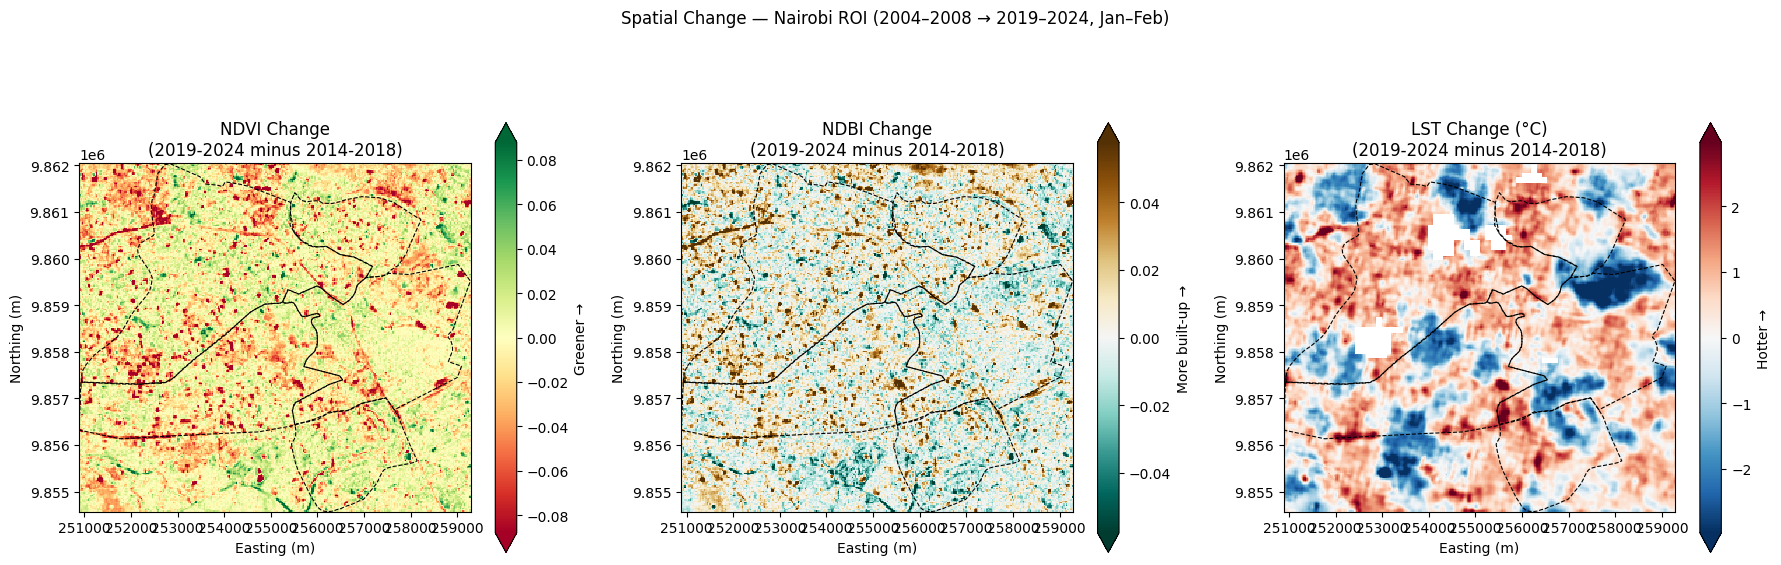

In [61]:
# Compute change: latest period minus earliest period
first_period = PERIOD_ORDER[0]
last_period = PERIOD_ORDER[-1]

if first_period in period_means and last_period in period_means:
    ndvi_change = (
        period_means[last_period]['spectral'].sel(band=1) -
        period_means[first_period]['spectral'].sel(band=1)
    )
    ndbi_change = (
        period_means[last_period]['spectral'].sel(band=2) -
        period_means[first_period]['spectral'].sel(band=2)
    )
    lst_change = (
        period_means[last_period]['lst'].sel(band=1) -
        period_means[first_period]['lst'].sel(band=1)
    )

    roi_utm = roi_gdf.to_crs(utm_crs)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    plot_configs = [
        (ndvi_change, 'NDVI Change', 'RdYlGn', 'Greener →'),
        (ndbi_change, 'NDBI Change', 'BrBG_r',  'More built-up →'),
        (lst_change,  'LST Change (°C)', 'RdBu_r', 'Hotter →'),
    ]

    for ax, (data, title, cmap, cbar_label) in zip(axes, plot_configs):
        absmax = float(abs(data).quantile(0.98))  # robust symmetric scale
        im = data.plot(
            ax=ax,
            cmap=cmap,
            vmin=-absmax,
            vmax=absmax,
            add_colorbar=True,
            cbar_kwargs={'label': cbar_label, 'shrink': 0.8},
        )
        roi_utm.boundary.plot(ax=ax, color='black', linewidth=0.8, linestyle='--')
        ax.set_title(f'{title}\n({last_period} minus {first_period})')
        ax.set_xlabel('Easting (m)')
        ax.set_ylabel('Northing (m)')

    fig.suptitle('Spatial Change — Nairobi ROI (2004–2008 → 2019–2024, Jan–Feb)', y=1.02)
    plt.tight_layout()
    plt.savefig('../images/spatial_change_maps.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Need both first and last period rasters. Run the raster extraction cell first.')

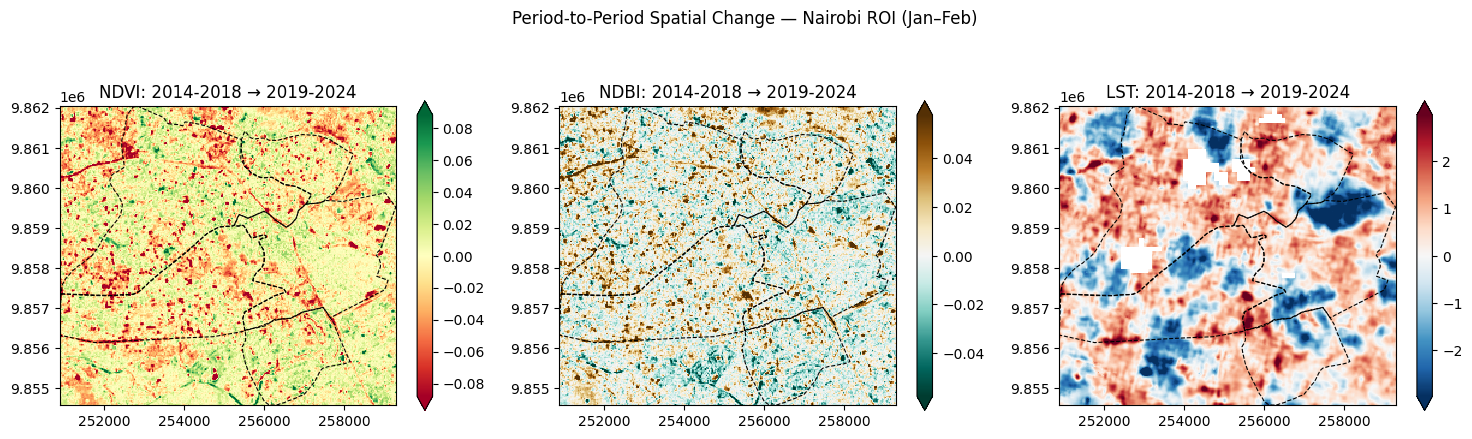

In [62]:
# Per-period change grid: each column is a variable, each row is a consecutive period transition
transitions = [
    (PERIOD_ORDER[i], PERIOD_ORDER[i + 1])
    for i in range(len(PERIOD_ORDER) - 1)
    if PERIOD_ORDER[i] in period_means and PERIOD_ORDER[i + 1] in period_means
]

if transitions:
    n_transitions = len(transitions)
    fig, axes = plt.subplots(n_transitions, 3, figsize=(15, 4.5 * n_transitions))
    if n_transitions == 1:
        axes = [axes]

    for row, (p_from, p_to) in enumerate(transitions):
        changes = {
            'NDVI': (period_means[p_to]['spectral'].sel(band=1) - period_means[p_from]['spectral'].sel(band=1), 'RdYlGn'),
            'NDBI': (period_means[p_to]['spectral'].sel(band=2) - period_means[p_from]['spectral'].sel(band=2), 'BrBG_r'),
            'LST':  (period_means[p_to]['lst'].sel(band=1)      - period_means[p_from]['lst'].sel(band=1),      'RdBu_r'),
        }
        for col, (var, (data, cmap)) in enumerate(changes.items()):
            ax = axes[row][col]
            absmax = float(abs(data).quantile(0.98))
            data.plot(ax=ax, cmap=cmap, vmin=-absmax, vmax=absmax,
                      add_colorbar=True, cbar_kwargs={'shrink': 0.8})
            roi_utm.boundary.plot(ax=ax, color='black', linewidth=0.8, linestyle='--')
            ax.set_title(f'{var}: {p_from} → {p_to}')
            ax.set_xlabel('')
            ax.set_ylabel('')

    fig.suptitle('Period-to-Period Spatial Change — Nairobi ROI (Jan–Feb)', y=1.01)
    plt.tight_layout()
    plt.savefig('../images/period_change_grid.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Not enough periods with rasters loaded for transition maps.')